# SCC0276 - Aprendizado de Máquina - EXERCÍCIO 5

1. Arthur Henrique Silva de Araujo - 14651458
2. Leonardo Doro Demore - 15674786


# Imports

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np

# Criando um conjunto de dados sintético

Para os exemplos desta semana, iremos utilizar um [conjunto de dados sintético](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html). Este conjunto de dados corresponde a exemplos com 2 atributos que correspondem a coordenadas X e Y para visualização 2D. 

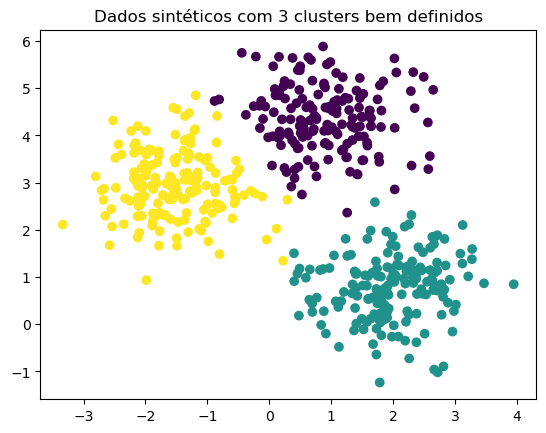

In [2]:
X, y = make_blobs(centers=3, cluster_std=0.7, n_samples=500, random_state=0)

plt.scatter(X[:, 0], X[:, 1], c=y) # colorindo os pontos de acordo com seus rótulos
plt.title("Dados sintéticos com 3 clusters bem definidos")
plt.show()

# 1) K-Vizinhos mais Próximos

Dando prosseguimento para os exercícios, agora iremos avaliar o modelo [KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

1) Divida o "X" e "y" sintéticos gerados anteriormente em treino e teste. Utilize 20% dos dados para teste, uma divisão estratificada e a *seed* 2026 para gerar os conjuntos. 
3) Seguindo a linha de exercícios das semanas anteriores, avalie três variações do KNN com parâmetros diferentes. Armazene os modelos treinados pois eles serão utilizados no próximo exercício. Como métricas, utilize acurácia, precisão e revocação.

In [3]:
# Divisão treino/teste (20% teste), estratificada e com seed 2026
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2026
)

In [4]:
# Treino e avaliação de 3 variações de KNN
knn_configs = [
    {"nome": "KNN_k3_uniform", "n_neighbors": 3, "weights": "uniform", "metric": "minkowski", "p": 2},
    {"nome": "KNN_k5_distance", "n_neighbors": 5, "weights": "distance", "metric": "minkowski", "p": 2},
    {"nome": "KNN_k11_manhattan", "n_neighbors": 11, "weights": "uniform", "metric": "minkowski", "p": 1},
]

knn_models = {}
resultados_knn = []

for cfg in knn_configs:
    modelo = KNeighborsClassifier(
        n_neighbors=cfg["n_neighbors"],
        weights=cfg["weights"],
        metric=cfg["metric"],
        p=cfg["p"],
    )
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    knn_models[cfg["nome"]] = modelo
    resultados_knn.append(
        {
            "modelo": cfg["nome"],
            "acuracia": accuracy_score(y_test, y_pred),
            "precisao_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "revocacao_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        }
    )

resultados_knn = pd.DataFrame(resultados_knn).sort_values(by="acuracia", ascending=False).reset_index(drop=True)
resultados_knn

,modelo,acuracia,precisao_macro,revocacao_macro
0,KNN_k5_distance,1.00,1.000000,1.000000
1,KNN_k11_manhattan,1.00,1.000000,1.000000
2,KNN_k3_uniform,0.99,0.990196,0.989899


# 2) K-Médias

O objetivo deste exercício é avaliar o algoritmo de agrupamento [K-Médias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

1) Avalie K-Médias, variando o K de 1 a 10. Configure a *seed* do modelo para 2026. Armazene a inércia de cada modelo (armazenado na variável '*inertia_*') em uma lista para análise no próximo item.
2) Visualize as inércias de cada K em um gráfico de linha. O eixo Y deve corresponder aos valores de inércia. O eixo X deve corresponder aos valores K testados.
3) Usando o conceito da regra do cotovelo (["*Elbow rule*"](https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/)), identifique o número ideal de clusters (valor K).
4) Visualize os agrupamentos gerados adaptando o código de visualização usado acima. Utilize clusters preditos pelo melhor K-Means (usando o melhor K), como parâmetro "c" do "*plt.scatter*". Use oos dados sem pré-processamento para a visualização.


In [5]:
# Treinando K-Médias para K de 1 a 10 e armazenando inércias
k_values = list(range(1, 11))
inertias = []
kmeans_models = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=2026, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    kmeans_models[k] = kmeans

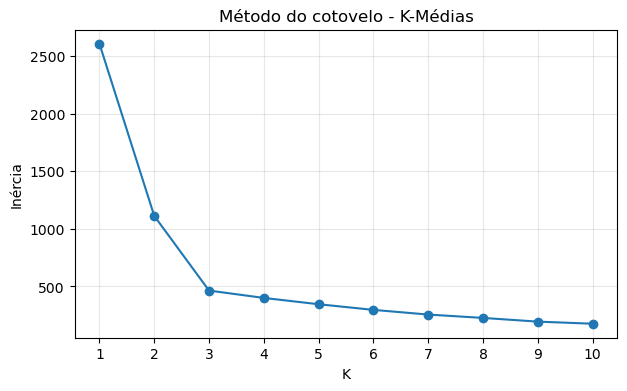

Melhor K pelo método do cotovelo: 3


In [6]:
# Gráfico de linha das inércias
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xticks(k_values)
plt.xlabel("K")
plt.ylabel("Inércia")
plt.title("Método do cotovelo - K-Médias")
plt.grid(alpha=0.3)
plt.show()

# Identificação automática do cotovelo (maior distância à reta entre os extremos)
p1 = np.array([k_values[0], inertias[0]], dtype=float)
p2 = np.array([k_values[-1], inertias[-1]], dtype=float)
line_vec = p2 - p1
line_norm = np.linalg.norm(line_vec)

distancias = []
for k, inertia in zip(k_values, inertias):
    p = np.array([k, inertia], dtype=float)
    if line_norm == 0:
        dist = 0.0
    else:
        det = line_vec[0] * (p[1] - p1[1]) - line_vec[1] * (p[0] - p1[0])
        dist = np.abs(det) / line_norm
    distancias.append(dist)

best_k = k_values[int(np.argmax(distancias))]
best_kmeans = kmeans_models[best_k]
clusters_pred = best_kmeans.labels_

print(f"Melhor K pelo método do cotovelo: {best_k}")

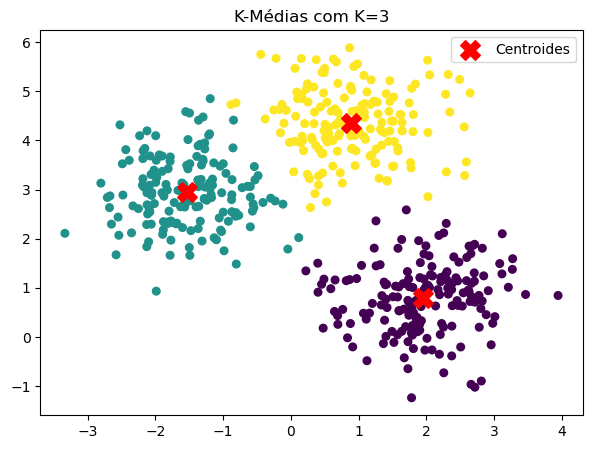

In [7]:
# Visualizando os agrupamentos com o melhor K
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters_pred, cmap="viridis", s=30)
plt.scatter(
    best_kmeans.cluster_centers_[:, 0],
    best_kmeans.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroides",
)
plt.title(f"K-Médias com K={best_k}")
plt.legend()
plt.show()

# 3) Avaliar um novo exemplo

O objetivo deste exercício é avaliar um novo exemplo (armazenenado na variável "new_example" a seguir) considerando os modelos KNN treinados no exercicio anterior. Para visualização, o novo exemplo é mostrado como um "ponto vermelho" nos códigos abaixo.

1) Determine para qual classe os KNNs treinados mapeiam o exemplo. Em outras palavras, use os KNNs treinados para predizer a classe do exemplo. Obs: caso a classe não tenha variado, experimente variar o parâmetro K do KNN.
2) Suponha que dois KNNs com valores K distintos tenham classificado o exemplo em classes diferentes. Neste caso, qual classificação você escolheria? Justifique sua resposta.

In [8]:
# Determinando novo exemplo
new_example = np.array([-1, 4.7])

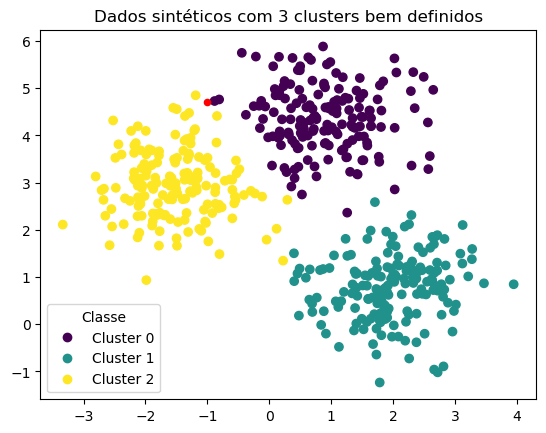

In [9]:
plt.title("Dados sintéticos com 3 clusters bem definidos")
fig = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(new_example[0], new_example[1], c='red', marker='o', s=20)

handles, _ = fig.legend_elements()
cluster_ids = np.unique(y)
labels = [f"Cluster {i}" for i in cluster_ids]

plt.legend(handles, labels, title="Classe", loc="best", frameon=True) 
plt.show()


In [10]:
# Predição do novo exemplo por cada KNN treinado
novo_exemplo = new_example.reshape(1, -1)
predicoes_knn = {nome: int(modelo.predict(novo_exemplo)[0]) for nome, modelo in knn_models.items()}

print("Predições para o novo exemplo:")
for nome, classe in predicoes_knn.items():
    print(f"- {nome}: classe {classe}")

classes_previstas = set(predicoes_knn.values())
if len(classes_previstas) == 1:
    classe_final = next(iter(classes_previstas))
    print(f"\nMesmo variando os parâmetros, todos os KNNs concordaram: classe final = {classe_final}")
else:
    # Em caso de conflito, escolhemos a classe do modelo com melhor desempenho no teste
    melhor_modelo = resultados_knn.sort_values(by=["acuracia", "precisao_macro", "revocacao_macro"], ascending=False).iloc[0]["modelo"]
    classe_final = predicoes_knn[melhor_modelo]
    print("\nHouve divergência entre os KNNs.")
    print(f"Escolha recomendada: classe {classe_final}, prevista pelo modelo {melhor_modelo}.")

print("\nJustificativa para o item 2:")
print(
    "Se dois KNNs divergirem, a melhor escolha é a previsão do modelo com melhor desempenho (acurácia,\n"
    "precisão e revocação), pois ele demonstrou melhor capacidade de generalização para dados não vistos."
)

Predições para o novo exemplo:
- KNN_k3_uniform: classe 0
- KNN_k5_distance: classe 0
- KNN_k11_manhattan: classe 0

Mesmo variando os parâmetros, todos os KNNs concordaram: classe final = 0

Justificativa para o item 2:
Se dois KNNs divergirem, a melhor escolha é a previsão do modelo com melhor desempenho (acurácia,
precisão e revocação), pois ele demonstrou melhor capacidade de generalização para dados não vistos.


# 4) Repita os exercícios para dados reais (opcional)

Repita os exercícios anteriores para algum conjunto de dados de classificação fornecido pelo [sklearn](https://scikit-learn.org/stable/api/sklearn.datasets.html). Note que os exercícios desta semana **não aplicaram nenhum pré-processamento** nos dados sintéticos, para garantir que os comportamentos esperados sejam observados. Quando avaliar dados diferentes, lembre-se de utilizar padronização ou normalização.  

## Questões teóricas para estudo

Não é necessário responder as perguntas a seguir para completar a atividade prática. Utilize as perguntas para estudo posteriormente.

- O que é uma medida de distância? Quais propriedades uma função deve satisfazer para ser considerada uma métrica?
- No contexto de agrupamento, quando se deve utilizar a distância euclidiana? Quando utilizar a distância de cosseno?
- Explique o problema da maldição da dimensionalidade no contexto de medidas de distância.
- Descreva como o algoritmo KNN realiza classificação.
- Como podemos adaptar o KNN para regressão?
- Por que o KNN é chamado de método “lazy learning”?
- Descreva o algoritmo do K-Médias.
- O que representam os centroides do K-Médias?
- Como a inicialização dos centroides afeta o resultado do K-Médias?

